# Obtención de datos

A partir del archivo CSV, obtenemos los datos y creamos el dataframe.

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv("historial_clinico.csv")
df

,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,tension,sexo,fumador
0,75,582,0,20,265000.00,1.9,130,4,1,0,20,0,5
1,55,7861,0,38,263358.03,1.1,136,6,1,0,14,0,5
2,65,146,0,20,162000.00,1.3,129,7,1,0,14,0,300
3,50,111,0,20,210000.00,1.9,137,7,1,1,14,0,5
4,65,160,1,20,327000.00,2.7,116,8,1,1,14,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62,61,1,38,155000.00,1.1,143,270,0,0,16,0,60
295,55,1820,0,38,270000.00,1.2,139,271,0,0,12,1,0
296,45,2060,1,60,742000.00,0.8,138,278,0,0,12,1,0
297,45,2413,0,38,140000.00,1.4,140,280,0,0,12,0,60


Una vez obtenido los datos, lo separamos en X e y.
También separaremos los datos en entrenamiento y test.

In [36]:
X = df.drop("fallecimiento", axis=1)
y = df["fallecimiento"]

#Hacemos train_test_split estratificado por y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, stratify=y, random_state=10)


Ahora hacemos una primera aproximación usando Logistic Regression.

In [37]:
#Comprobaremos cuantos valores existen en la columna objetivo
y.value_counts()

fallecimiento
0    203
1     96
Name: count, dtype: int64

# Logistic Regression

Dado que existe cierta disparidad entre los valores de la columna objetivo, usaremos LogisticRegression con class_weigth="balanced" para que el modelo tenga en cuenta esta disparidad.

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced")

lr.fit(X_train, y_train)

print("Score del train", lr.score(X_train, y_train))
print("Score del test", lr.score(X_test, y_test))

Score del train 0.8169642857142857
Score del test 0.7466666666666667


c:\Users\David\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Realizaremos un cross validate

In [39]:
#Creamos un KFold estratificado el cual usaremos en la validación de los modelos que creemos
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True)

In [40]:
from sklearn.model_selection import cross_validate
cv = cross_validate(lr, X_train, y_train, cv=skf, return_train_score=True)

print("Media del train", cv["train_score"].mean())
print("Media del score", cv["test_score"].mean())

print("Score del train", lr.score(X_train, y_train))
print("Score del test", lr.score(X_test, y_test))

Media del train 0.8192054624456858
Media del score 0.7948484848484847
Score del train 0.8169642857142857
Score del test 0.7466666666666667


c:\Users\David\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Calculamos métricas para clasificación

In [41]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

y_pred = lr.predict(X_test)

b_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Balanced Accuracy: 0.7144607843137255
Precision: 0.6
Recall: 0.625
F1 Score: 0.6122448979591837


In [42]:
from sklearn.metrics import classification_report
c_r = classification_report(y_test, y_pred, target_names=["No Fallecido", "Fallecido"])
print(c_r)

              precision    recall  f1-score   support

No Fallecido       0.82      0.80      0.81        51
   Fallecido       0.60      0.62      0.61        24

    accuracy                           0.75        75
   macro avg       0.71      0.71      0.71        75
weighted avg       0.75      0.75      0.75        75



Este modelo tiene un rendimiento moderado-bajo.
Tiene una baja precisión, alrededor del 50% lo que genera falsos positivos. Por otro lado, tiene un recall bastante aceptable, alrededor del 80%.

Comprobemos ahora la fiabilidad con una matriz de confusión

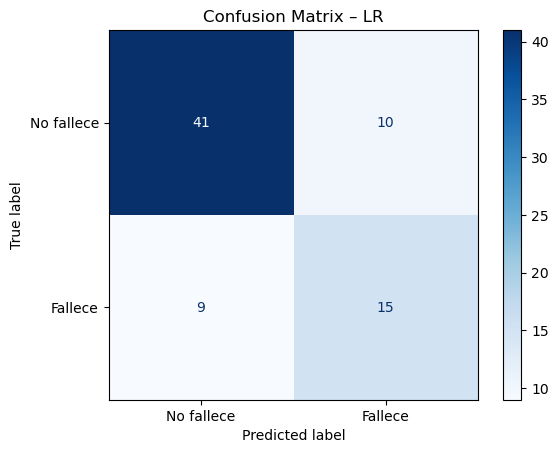

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix – LR")
plt.show()

# Análisis Discriminante Lineal

A continuación realizaremos un estimador de tipo ADL

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
#Realizamos la validacion cruzada
cv_lda = cross_validate(lda, X_train, y_train, cv=skf,return_train_score=True)

#Entrenamos
lda.fit(X_train, y_train)

print("Media del train", cv_lda["train_score"].mean())
print("Media del test", cv_lda["test_score"].mean())
print("Score del train", lda.score(X_train, y_train))
print("Score del test", lda.score(X_test, y_test))

Media del train 0.8973060211049038
Media del test 0.8793939393939393
Score del train 0.9017857142857143
Score del test 0.8266666666666667


Obtenemos muy buenos resultados con el modelo de Análisis de Discriminación Lineal, con una tasa de acierto sobre el 90% para el conjunto de entrenamiento y el 85% para el conjunto de validación.

A continuación, procedemos a hacer el calculo de las métricas del modelo.

In [45]:
cr_lda = classification_report(y_test, lda.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_lda)

              precision    recall  f1-score   support

No Fallecido       0.83      0.94      0.88        51
   Fallecido       0.82      0.58      0.68        24

    accuracy                           0.83        75
   macro avg       0.83      0.76      0.78        75
weighted avg       0.83      0.83      0.82        75



Balanced Accuracy: 0.7622549019607843
Precision: 0.8235294117647058
Recall: 0.5833333333333334
F1 Score: 0.6829268292682927


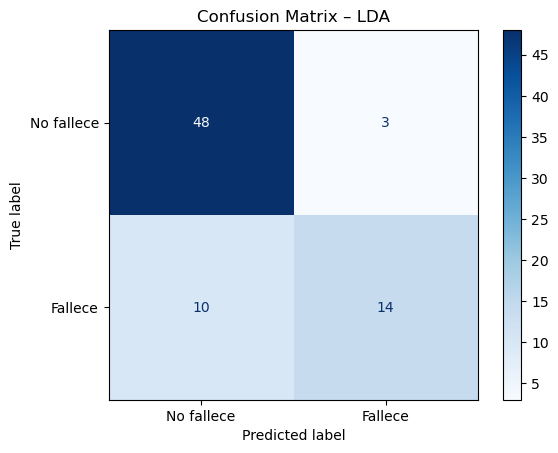

In [46]:
y_pred = lda.predict(X_test)

b_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix – LDA")
plt.show()

Con el modelo de Análisis de Discriminación Lineal (LDA) se puede observar que tenemos muy buenos resultados, con unos Scores alrededor del 90% (train) y 85% (test).

# Análisis Discriminante Cuadrático

A continuación, procedemos a realizar el estudio con un modelo de ADC.

In [47]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

cld = QuadraticDiscriminantAnalysis()

#Realizamos validación cruzada
cv_cld = cross_validate(cld, X_train, y_train, cv=skf, return_train_score=True) #Usamos el skf de antes
#Entrenamos
cld.fit(X_train, y_train)

print("Media del train", cv_cld["train_score"].mean())
print("Media del test", cv_cld["test_score"].mean())
print("Score del train", cld.score(X_train, y_train))
print("Score del test", cld.score(X_test, y_test))

Media del train 0.8917442582247052
Media del test 0.8436363636363637
Score del train 0.8883928571428571
Score del test 0.7733333333333333


Obtenemos también muy buenos resultados, pero cabe recalcar que son ligeramente inferiores a los obtenidos con el Discriminante Lineal.

Realizamos el calculo de las métricas

In [48]:
cr_cld = classification_report(y_test, cld.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_cld)

              precision    recall  f1-score   support

No Fallecido       0.78      0.92      0.85        51
   Fallecido       0.73      0.46      0.56        24

    accuracy                           0.77        75
   macro avg       0.76      0.69      0.71        75
weighted avg       0.77      0.77      0.76        75



Balanced Accuracy: 0.6899509803921569
Precision: 0.7333333333333333
Recall: 0.4583333333333333
F1 Score: 0.5641025641025641


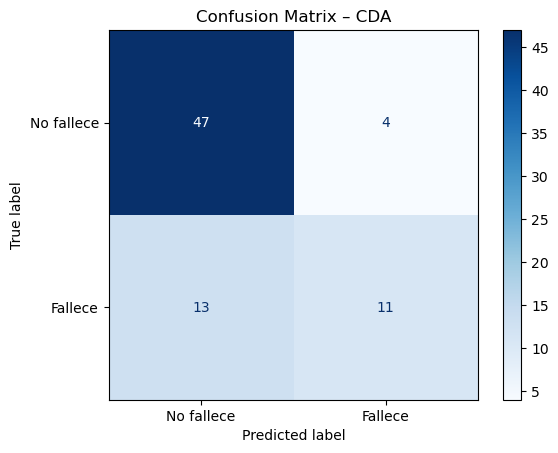

In [49]:
y_pred = cld.predict(X_test)

b_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix – CDA")
plt.show()

# SVC y GridSearchCV

A continuación, realizaremos los estudios con modelos de SVC

In [50]:
hiperparametros = {
    'C': [1, 10, 50, 100,200, 300, 400, 60, 70, 80, 500],
    'gamma': [ 0.001, 0.01, 0.1, 1, 10],
    'class_weight': ['balanced']
}

In [70]:
len(y_test)

75

In [51]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc_rbf = SVC(kernel="rbf")
gs_rbf = GridSearchCV(svc_rbf, hiperparametros, cv=skf)

gs_rbf.fit(X_train, y_train)#Lo entrenamos

print("Mejor score:", gs_rbf.best_score_)
print("Mejor C:", gs_rbf.best_params_['C'])
print("Mejor gamma:", gs_rbf.best_params_['gamma'])
print("Mejor class_weight: ", gs_rbf.best_params_['class_weight'])
print("Score del test:", gs_rbf.best_estimator_.score(X_test, y_test))

Mejor score: 0.6785858585858585
Mejor C: 1
Mejor gamma: 0.001
Mejor class_weight:  balanced
Score del test: 0.68


Obtenemos el mejor modelo calculado por el GirdSearch y calculamos las métricas

In [52]:
mejor_estimador = gs_rbf.best_estimator_
cr_svc_rbf = classification_report(y_test, mejor_estimador.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_svc_rbf)

              precision    recall  f1-score   support

No Fallecido       0.68      0.98      0.81        51
   Fallecido       0.50      0.04      0.08        24

    accuracy                           0.68        75
   macro avg       0.59      0.51      0.44        75
weighted avg       0.63      0.68      0.57        75



Balanced Accuracy: 0.5110294117647058
Precision: 0.5
Recall: 0.041666666666666664
F1 Score: 0.07692307692307693
75


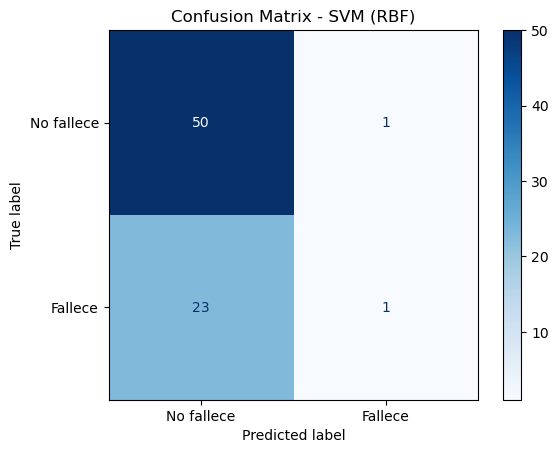

In [ ]:
#Machacamos al anterior creado
svc_rbf = gs_rbf.best_estimator_

#Realizamos métricas
y_pred = svc_rbf.predict(X_test)

b_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix - SVM (RBF)")
plt.show()

“El warning UndefinedMetricWarning aparece porque el clasificador no predice ninguna muestra de la clase positiva, lo que provoca que la precisión no esté definida. Este comportamiento es consecuencia del desbalance del conjunto de datos y de la tendencia del modelo a priorizar la clase mayoritaria.”

--------------------------------

In [72]:
hiperparametros = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1],
    'coef0': [0, 1, 5],
    'class_weight': ['balanced']  
}


In [73]:
svc_sigmoid = SVC(kernel="sigmoid")
gs_sigmoid = GridSearchCV(svc_sigmoid, hiperparametros, cv=skf)

gs_sigmoid.fit(X_train, y_train)
print("Mejor score:", gs_sigmoid.best_score_)
print("Mejor C:", gs_sigmoid.best_params_['C'])
print("Mejor gamma:", gs_sigmoid.best_params_['gamma'])
print("Mejor class_weight:", gs_sigmoid.best_params_['class_weight'])
print("Score del test:", gs_sigmoid.best_estimator_.score(X_test, y_test))

Mejor score: 0.5274747474747474
Mejor C: 10
Mejor gamma: 0.001
Mejor class_weight: balanced
Score del test: 0.32


In [74]:
mejor_estimador = gs_sigmoid.best_estimator_
cr_svc_rbf = classification_report(y_test, mejor_estimador.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_svc_rbf)

              precision    recall  f1-score   support

No Fallecido       0.00      0.00      0.00        51
   Fallecido       0.32      1.00      0.48        24

    accuracy                           0.32        75
   macro avg       0.16      0.50      0.24        75
weighted avg       0.10      0.32      0.16        75



c:\Users\David\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\David\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\David\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Balanced Accuracy: 0.5
Precision: 0.32
Recall: 1.0
F1 Score: 0.48484848484848486


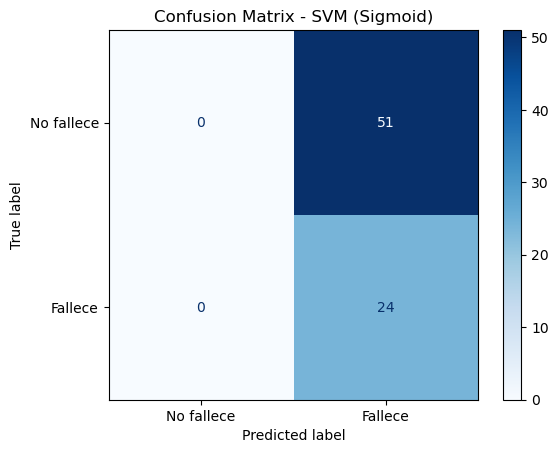

In [75]:
#Asignamos el mejor estimador a la variable svc_sigmoid
svc_sigmoid = gs_sigmoid.best_estimator_

#Hacemos una predicción para calcular las métricas
y_pred_sigmoid = svc_sigmoid.predict(X_test)

#Calculamos las métricas
b_accuracy = balanced_accuracy_score(y_test, y_pred_sigmoid)
precision = precision_score(y_test, y_pred_sigmoid)
recall = recall_score(y_test, y_pred_sigmoid)
f1 = f1_score(y_test, y_pred_sigmoid)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred_sigmoid)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix - SVM (Sigmoid)")
plt.show()

“El warning UndefinedMetricWarning aparece porque el clasificador no predice ninguna muestra de la clase positiva, lo que provoca que la precisión no esté definida. Este comportamiento es consecuencia del desbalance del conjunto de datos y de la tendencia del modelo a priorizar la clase mayoritaria.”

---

A continuación, realizaremos otro SVC con kernel polinómico

In [76]:

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__degree': [2, 3, 4],
    'svc__coef0': [0, 1],
    'svc__class_weight': [None, 'balanced']
}


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='poly', gamma = 'scale'))
])

gs_poly = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=skf)
gs_poly.fit(X_train, y_train)

print("Mejor score CV:", gs_poly.best_score_)
print("Mejores parámetros:", gs_poly.best_params_)
print("Score en test:", gs_poly.score(X_test, y_test))

Mejor score CV: 0.8841414141414141
Mejores parámetros: {'svc__C': 0.1, 'svc__class_weight': None, 'svc__coef0': 1, 'svc__degree': 4}
Score en test: 0.8133333333333334


Realizamos la predicción y los cálculos de las métricas del modelo.

In [77]:
mejor_estimador = gs_poly.best_estimator_
cr_svc_rbf = classification_report(y_test, mejor_estimador.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_svc_rbf)

              precision    recall  f1-score   support

No Fallecido       0.79      0.98      0.88        51
   Fallecido       0.92      0.46      0.61        24

    accuracy                           0.81        75
   macro avg       0.86      0.72      0.74        75
weighted avg       0.83      0.81      0.79        75



Balanced Accuracy: 0.7193627450980392
Precision: 0.9166666666666666
Recall: 0.4583333333333333
F1 Score: 0.6111111111111112


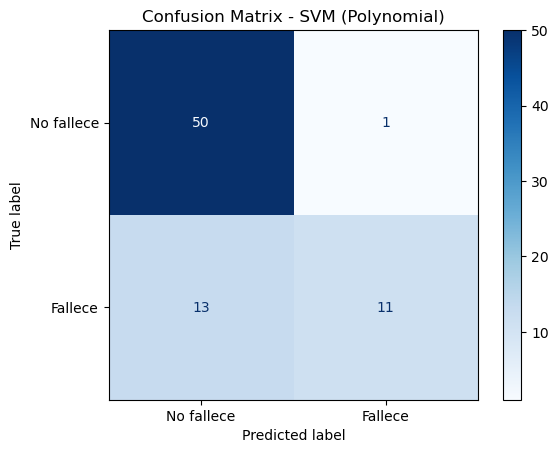

In [78]:
#Asignamos el mejor estimador a la variable svc_poly
svc_poly = gs_poly.best_estimator_

#Realizamos una predicción para calcular las métricas
y_pred_poly = svc_poly.predict(X_test)

#Calculamos las métricas
b_accuracy = balanced_accuracy_score(y_test, y_pred_poly)
precision = precision_score(y_test, y_pred_poly)
recall = recall_score(y_test, y_pred_poly)
f1 = f1_score(y_test, y_pred_poly)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred_poly)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix - SVM (Polynomial)")
plt.show()

A continuación, hay un código comentado ya que al ejecutarse entra en bucle, no sabemos el motivo.

In [79]:
# hiperparametros = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 'auto'],
#     'degree': [2, 3],
#     'class_weight': [None, 'balanced'], 
#     'coef0': [0.1, 0.5, 1.0]
# }


In [80]:
# svc_poly_2 = SVC(kernel="poly")
# gs_poly_2 = GridSearchCV(svc_poly_2, hiperparametros, cv=skf, verbose = 2)

# gs_poly_2.fit(X_train, y_train)#Lo entrenamos

# print("Mejor score:", gs_poly_2.best_score_)
# print("Mejor C:", gs_poly_2.best_params_['C'])
# print("Mejor gamma:", gs_poly_2.best_params_['gamma'])
# print("Score del test:", gs_poly_2.best_estimator_.score(X_test, y_test))


# Árbol de Decisiones

In [81]:
from sklearn.tree import DecisionTreeClassifier

#Vamos a probar con el criterio de gini puesto que hay mas columnas que son de datos continuos
arbol = DecisionTreeClassifier(criterion = "gini", class_weight="balanced")

#Realizamos el entrenamiento
arbol.fit(X_train, y_train)

print("Score del train", arbol.score(X_train, y_train))
print("Score del test", arbol.score(X_test, y_test))

Score del train 1.0
Score del test 0.9733333333333334


In [82]:
cv_arbol = cross_validate(arbol, X_train, y_train, cv=skf, return_train_score=True)

print("Media del train", cv_arbol["train_score"].mean())
print("Media del test", cv_arbol["test_score"].mean())

Media del train 1.0
Media del test 0.9732323232323232


In [83]:
cr_arbol = classification_report(y_test, arbol.predict(X_test), target_names=["No Fallecido", "Fallecido"])
print(cr_arbol)

              precision    recall  f1-score   support

No Fallecido       1.00      0.96      0.98        51
   Fallecido       0.92      1.00      0.96        24

    accuracy                           0.97        75
   macro avg       0.96      0.98      0.97        75
weighted avg       0.98      0.97      0.97        75



Balanced Accuracy: 0.9803921568627452
Precision: 0.9230769230769231
Recall: 1.0
F1 Score: 0.96


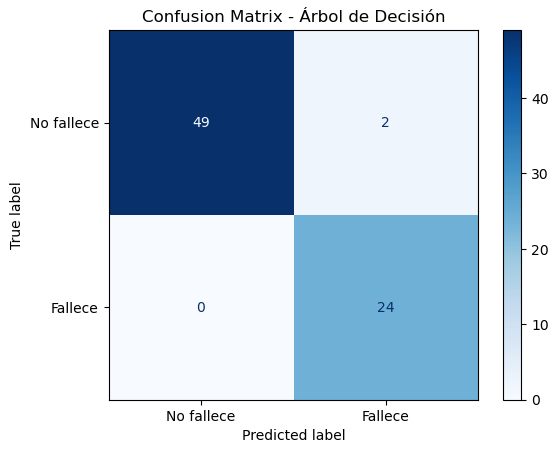

In [84]:
#Predicción para calcular métricas
y_pred_arbol = arbol.predict(X_test)

#Calculamos las métricas
b_accuracy = balanced_accuracy_score(y_test, y_pred_arbol)
precision = precision_score(y_test, y_pred_arbol)
recall = recall_score(y_test, y_pred_arbol)
f1 = f1_score(y_test, y_pred_arbol)

print(f"Balanced Accuracy: {b_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_test, y_pred_arbol)
cmd = ConfusionMatrixDisplay(cm, display_labels = ["No fallece", "Fallece"])
cmd.plot(cmap="Blues")
cmd.ax_.set_title("Confusion Matrix - Árbol de Decisión")
plt.show()

Obtenemos un gran modelo con muy buenos resultados. Procedemos a visualizar de forma gráfica el árbol.

Text(0.5, 1.0, 'Árbol de Decisión')

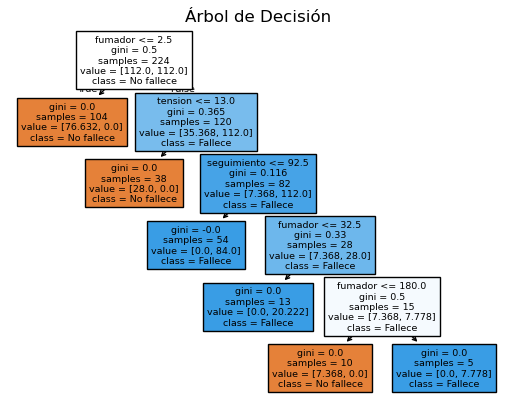

In [85]:
from sklearn.tree import plot_tree
plot_tree(arbol, filled=True, feature_names=X.columns, class_names=["No fallece", "Fallece"])
plt.title("Árbol de Decisión")

Después de haber hecho un estudio de cada modelo, para el dataset proporcionado, el mejor de ellos es ARBOL DE DECISIONES.

# OPCIONAL. Guardar modelo usando Pickle

In [86]:
import pickle
with open("modelo_arbol_decision.pkl", "wb") as f:
    pickle.dump(arbol, f)